# Clase 11 — Estadística Descriptiva

Trabajas en el área de análisis de una consultora inmobiliaria. Un cliente quiere invertir en propiedades en Argentina y necesita un informe que responda preguntas concretas sobre el mercado antes de tomar cualquier decisión.

Te acaban de mandar acceso a un dataset real de Properati, uno de los portales inmobiliarios más grandes de América Latina, con miles de propiedades publicadas en Argentina. No está limpio, no está listo para analizar, y nadie te va a decir qué problemas tiene. Tu trabajo es encontrarlos, limpiarlos y responder las preguntas del cliente con números que puedas defender.

## Obtener el dataset

El dataset está disponible en Kaggle de forma gratuita:

👉 **[Properati Argentina Dataset — Kaggle](https://www.kaggle.com/datasets/alejandroczernikier/properati-argentina-dataset)**

Descarga el archivo CSV y guardalo en la misma carpeta donde vas a trabajar. Después cargalo:

## Ejercicio 1 — Exploración inicial: ¿qué hay adentro?

Antes de responder cualquier pregunta del cliente, necesitás entender con qué estás trabajando. No asumas nada — explorá.

**Consigna:** Sin limpiar nada todavía, responde estas preguntas en comentarios:

- ¿Cuántas propiedades y cuántas columnas tiene el dataset?
- ¿Qué columnas numéricas hay? ¿Cuáles vas a necesitar para el análisis?
- ¿Cuántos nulos tiene cada columna relevante? (precio, superficie, ambientes, provincia, tipo de propiedad)
- ¿Hay columnas con nombres en inglés que debas entender antes de continuar? Renombra al menos las columnas principales a español.
- ¿Qué tipos de propiedad hay? ¿Qué provincias aparecen?
- ¿Cuáles tienen más registros?

In [24]:
import pandas as pd
df = pd.read_csv("entrenamiento.csv")

In [25]:
df2 = df.copy()

In [26]:
df2.info()
df2[["price", "surface_total", "property_type", "rooms", "l1", "l2", "l3", "l4", "l5", "l6"]].isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 992192 entries, 0 to 992191
Data columns (total 25 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               992192 non-null  int64  
 1   ad_type          992192 non-null  str    
 2   start_date       992192 non-null  str    
 3   end_date         992192 non-null  str    
 4   created_on       992192 non-null  str    
 5   lat              838994 non-null  float64
 6   lon              839929 non-null  float64
 7   l1               992192 non-null  str    
 8   l2               992192 non-null  str    
 9   l3               934737 non-null  str    
 10  l4               225395 non-null  str    
 11  l5               4711 non-null    str    
 12  l6               0 non-null       float64
 13  rooms            503045 non-null  float64
 14  bedrooms         390699 non-null  float64
 15  bathrooms        773021 non-null  float64
 16  surface_total    448164 non-null  float64
 17  su

price             44381
surface_total    544028
property_type         0
rooms            489147
l1                    0
l2                    0
l3                57455
l4               766797
l5               987481
l6               992192
dtype: int64

In [123]:
df2.rename(columns={"rooms": "habitaciones","bathrooms": "baños","currency":"moneda","price_period":"precio_periodo","surface_total":"superficie_total","surface_covered":"superficie_cubierta","property_type":"tipo_propiedad","title": "titulo","operation_type":"operacion_tipo","price":"precio"}, inplace=True)
df2

,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,...,baños,superficie_total,superficie_cubierta,moneda,precio_periodo,titulo,description,tipo_propiedad,operacion_tipo,precio
0,556713,Propiedad,2019-11-29,9999-12-31,2019-11-29,-58.442399,-34.573623,Argentina,Capital Federal,Colegiales,...,2.0,NaN,NaN,USD,NaN,"Departamento en Venta en Belgrano, Capital fed...","Sup total por escritura: 96,47 m2 (cubiertos: ...",Departamento,Venta,259000.0
1,192912,Propiedad,2020-06-05,2020-06-08,2020-06-05,-58.430493,-34.606620,Argentina,Capital Federal,Almagro,...,2.0,77.0,67.0,USD,NaN,Departamento de 3 ambientes en Venta en Almagro,Excelente departamento de tres ambientes ampli...,Departamento,Venta,235500.0
2,238224,Propiedad,2020-07-01,9999-12-31,2020-07-01,-58.491760,-34.574123,Argentina,Capital Federal,Villa Urquiza,...,1.0,60.0,55.0,USD,NaN,Andonaegui 2600 4° - - Departamento en Venta,Excelente 3 ambientes al frente con balcón. Vi...,Departamento,Venta,175000.0
3,257134,Propiedad,2019-08-17,9999-12-31,2019-08-17,-58.420737,-34.631770,Argentina,Capital Federal,Boedo,...,1.0,74.0,47.0,USD,NaN,PH Venta Boedo 2 amb Patio,Corredor Responsable: MARCELO TRUJILLO - CPI ...,PH,Venta,140000.0
4,521738,Propiedad,2019-08-05,2019-08-31,2019-08-05,-58.429983,-34.607225,Argentina,Capital Federal,Almagro,...,1.0,66.0,64.0,USD,NaN,Venta 3 Ambientes - Almagro - Balcón - Ameniti...,Corredor Responsable: Marcelo Trujillo - CUCIC...,Departamento,Venta,173000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992187,999996,Propiedad,2020-01-09,2020-04-27,2020-01-09,-57.575169,-38.042062,Argentina,Buenos Aires Costa Atlántica,Mar del Plata,...,5.0,NaN,NaN,USD,NaN,Venta en Bloque,Venta en bloque de esta importante propiedad. ...,Casa,Venta,190000.0
992188,999997,Propiedad,2020-01-09,2020-04-27,2020-01-09,-68.860929,-32.953935,Argentina,Mendoza,Cuadro Benegas,...,5.0,NaN,NaN,USD,NaN,PALMARES SEGUNDA ETAPA,RIVEROS PROPIEDADES VENDE: Casa Desarrollada E...,Casa,Venta,520000.0
992189,999998,Propiedad,2020-01-09,2020-04-27,2020-01-09,-57.963191,-34.920051,Argentina,Bs.As. G.B.A. Zona Sur,La Plata,...,5.0,NaN,NaN,ARS,NaN,"Departamento en Alquiler, 44mts, 0 dormitorios...",16 N&deg;706 y 46 se alquila monoambiente e...,Departamento,Alquiler,12000.0
992190,999999,Propiedad,2020-01-09,2020-04-28,2020-01-09,-57.549815,-38.020436,Argentina,Buenos Aires Costa Atlántica,Mar del Plata,...,5.0,NaN,NaN,USD,NaN,IMPORTANTE RESIDENCIA EN DIVINO ROSTRO,En importante ubicación del tradicional Barrio...,Casa,Venta,550000.0


## Ejercicio 2 — Limpieza: decisiones justificadas

El dataset tiene problemas que van a afectar el análisis si no los tratás antes.

**Consigna:** Aplica las siguientes limpiezas y justifica cada decisión en un comentario:

- Quedate solo con propiedades en venta en USD (filtra por operation = 'sell' y currency = 'USD'). Responde ¿Por qué tiene sentido trabajar solo en USD?
- Eliminar filas donde el precio o la superficie sean nulos ¿Qué porcentaje del dataset estás perdiendo?
- Filtrar precios que parezcan errores evidentes ¿Tiene sentido una propiedad que vale $1 USD? ¿Y una de $50 millones?.Define un criterio para filtrar y justificalo.
- Quedate solo con los tipos de propiedad principales (por ejemplo: Departamento, Casa, PH) ¿Por qué descartas los demás?
- Al terminar: ¿cuántas filas quedaron? ¿Qué porcentaje del original?

In [151]:

# Filtro 1: ventas en USD
df_filtrado = df2[(df2["operacion_tipo"] == "Venta") &(df2["moneda"] == "USD")
]

# Filtro 2: eliminar nulos
df_filtrado = df_filtrado.dropna(subset=["precio", "superficie_total"]
)

# Filtro 3: rango de precios
df_filtrado = df_filtrado[
    (df_filtrado["precio"] >= 50000) &
    (df_filtrado["precio"] <= 1000000)
]

# Filtro 4: tipo de propiedad
df_filtrado = df_filtrado[
    (df_filtrado["tipo_propiedad"] == "Departamento") |
    (df_filtrado["tipo_propiedad"] == "Casa") |
    (df_filtrado["tipo_propiedad"] == "PH")
]
df_filtrado

,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,...,baños,superficie_total,superficie_cubierta,moneda,precio_periodo,titulo,description,tipo_propiedad,operacion_tipo,precio
1,192912,Propiedad,2020-06-05,2020-06-08,2020-06-05,-58.430493,-34.606620,Argentina,Capital Federal,Almagro,...,2.0,77.0,67.0,USD,NaN,Departamento de 3 ambientes en Venta en Almagro,Excelente departamento de tres ambientes ampli...,Departamento,Venta,235500.0
2,238224,Propiedad,2020-07-01,9999-12-31,2020-07-01,-58.491760,-34.574123,Argentina,Capital Federal,Villa Urquiza,...,1.0,60.0,55.0,USD,NaN,Andonaegui 2600 4° - - Departamento en Venta,Excelente 3 ambientes al frente con balcón. Vi...,Departamento,Venta,175000.0
3,257134,Propiedad,2019-08-17,9999-12-31,2019-08-17,-58.420737,-34.631770,Argentina,Capital Federal,Boedo,...,1.0,74.0,47.0,USD,NaN,PH Venta Boedo 2 amb Patio,Corredor Responsable: MARCELO TRUJILLO - CPI ...,PH,Venta,140000.0
4,521738,Propiedad,2019-08-05,2019-08-31,2019-08-05,-58.429983,-34.607225,Argentina,Capital Federal,Almagro,...,1.0,66.0,64.0,USD,NaN,Venta 3 Ambientes - Almagro - Balcón - Ameniti...,Corredor Responsable: Marcelo Trujillo - CUCIC...,Departamento,Venta,173000.0
5,383947,Propiedad,2019-10-23,2019-11-08,2019-10-23,-58.420780,-34.608640,Argentina,Capital Federal,Almagro,...,1.0,55.0,55.0,USD,NaN,Depto.tipo casa de 3 ambientes en Venta en Alm...,"Muy Lindo ph al contrafrente con 2 patios!, 80...",PH,Venta,155000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992168,999977,Propiedad,2020-01-09,2020-02-28,2020-01-09,-58.859391,-34.467469,Argentina,Bs.As. G.B.A. Zona Norte,Pilar,...,5.0,4000.0,400.0,USD,NaN,Distinguida casa en Martindale C.C ¡ Bajo de p...,Distinguida casa distribuida en 2 Hall de ent...,Casa,Venta,590000.0
992172,999981,Propiedad,2020-01-09,2020-02-28,2020-01-09,-58.651688,-34.399740,Argentina,Bs.As. G.B.A. Zona Norte,Tigre,...,5.0,270.0,270.0,USD,NaN,Increible casa Moderna Barrio Los Sauces - Nor...,"Increíble casa moderna, con excelente calidad ...",Casa,Venta,600000.0
992174,999983,Propiedad,2020-01-09,2020-02-28,2020-01-09,-58.567144,-34.474277,Argentina,Bs.As. G.B.A. Zona Norte,San Isidro,...,5.0,340.0,297.0,USD,NaN,Excelente casa totalmente restaurada en La Hor...,"Excelente, impecable, toda restaurada, muy bie...",Casa,Venta,620000.0
992177,999986,Propiedad,2020-01-09,2020-02-28,2020-01-09,-58.485104,-34.507781,Argentina,Bs.As. G.B.A. Zona Norte,Vicente López,...,5.0,1000.0,450.0,USD,NaN,Gran Casa estilo Inglés - Excelente Ubicación ...,"Excelente ubicación, en la parte más linda de ...",Casa,Venta,1000000.0


## Ejercicio 3 — Estadísticos del mercado general

Con el dataset limpio, calculá los estadísticos principales del precio en dólares para todo el mercado.

**Consigna:** Calcula para precio_usd, la media, mediana, moda, desviación estándar y percentiles 10, 25, 50, 75, 90, 99. Después responde en comentarios:

1. ¿La media y la mediana son similares o muy distintas? ¿Qué te dice esa diferencia sobre la distribución de precios?
2. ¿Entre qué valores se encuentra el 80% central de las propiedades? (entre P10 y P90)
3. ¿Cuánto cuesta el 1% más caro del mercado? ¿Eso afecta la media?
4. Grafica la distribución de precios con un histograma que muestre la media y la mediana como líneas verticales

La media es de 214.775 USD y la mediana 160.000 USD son distintas,lo que indica una diferencia de 54.775 USD y que tenemos una distribución de precios sesgada a la derecha lo que indica que existe un grupo de propiedades con precios altos que elevan la media.
P10 → El 10% de las propiedades tiene un precio menor o igual a 74.900 USD.
P90 → El 90% de las propiedades tiene un precio menor o igual a 430.000 USD.
El 1% de las propiedades más caras tienen un precio mayor o igual a 850.000 USD.

In [150]:
df_filtrado[["precio"]].describe()

,precio
count,209623.000000
mean,214775.775111
std,165212.312961
min,50000.000000
25%,100000.000000
50%,160000.000000
75%,270000.000000
max,1000000.000000


In [147]:
df_filtrado["precio"].quantile([0.10, 0.90])

0.1     74900.0
0.9    430000.0
Name: precio, dtype: float64

In [148]:
df_filtrado["precio"].quantile([0.99])

0.99    850000.0
Name: precio, dtype: float64

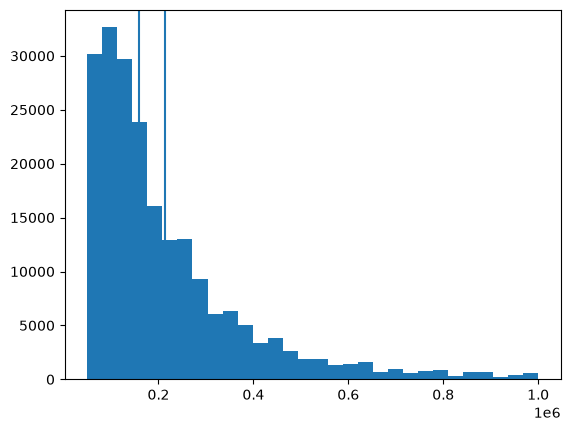

In [146]:
import matplotlib.pyplot as plt

plt.hist(df_filtrado["precio"], bins=30)
plt.axvline(df_filtrado["precio"].mean())
plt.axvline(df_filtrado["precio"].median())
plt.show()






## Ejercicio 4 — Precio por metro cuadrado: el indicador real

El precio absoluto de una propiedad no dice mucho sin contexto. El precio por metro cuadrado es el indicador estándar del sector para comparar mercados.

**Consigna:**

1. Calculá una columna nueva: precio_m2 = precio_usd / superficie_m2
2. Calculá media, mediana y desviación estándar de precio_m2 por tipo de propiedad
3. ¿Qué tipo de propiedad tiene el precio por m² más alto? ¿Tiene sentido para el mercado argentino?
4. Graficá la distribución de precio_m2 para cada tipo de propiedad en el mismo histograma (usá alpha=0.5 para transparencia)

In [160]:
##Calculo Precio por m2
df_filtrado["precio_m2"] = df_filtrado["precio"] / df_filtrado["superficie_total"]
df_filtrado[["precio_m2"]]



,precio_m2
1,3058.441558
2,2916.666667
3,1891.891892
4,2621.212121
5,2818.181818
...,...
992168,147.500000
992172,2222.222222
992174,1823.529412
992177,1000.000000


In [163]:
##Calculo de estadisticas descriptivas por precio_m2 departamento
df_estadistica_departamento = df_filtrado[(df_filtrado["precio_m2"] >= 0) & (df_filtrado["precio_m2"] <= 10000) & (df_filtrado["tipo_propiedad"] == "Departamento")]
df_estadistica_departamento[["precio_m2"]].describe()


,precio_m2
count,131263.000000
mean,2473.169284
std,946.066942
min,0.386055
25%,1823.898305
50%,2358.974359
75%,2979.898990
max,10000.000000


In [164]:
##Calculo de estadisticas descriptivas por precio_m2 casa
df_estadistica_casa = df_filtrado[(df_filtrado["precio_m2"] >= 0) & (df_filtrado["precio_m2"] <= 10000) & (df_filtrado["tipo_propiedad"] == "Casa")]
df_estadistica_casa[["precio_m2"]].describe()

,precio_m2
count,63454.000000
mean,1047.138016
std,703.222108
min,0.429741
25%,473.214286
50%,948.012232
75%,1484.815403
max,10000.000000


In [165]:
##Calculo de estadisticas descriptivas por precio_m2 PH
df_estadistica_ph = df_filtrado[(df_filtrado["precio_m2"] >= 0) & (df_filtrado["precio_m2"] <= 10000) & (df_filtrado["tipo_propiedad"] == "PH")]
df_estadistica_ph[["precio_m2"]].describe()

,precio_m2
count,14759.000000
mean,1688.442302
std,749.928957
min,0.943910
25%,1125.000000
50%,1638.655462
75%,2168.292683
max,8950.000000


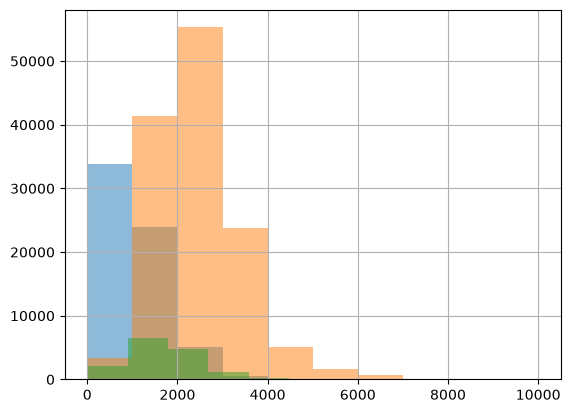

In [167]:
df_filtrado = df_filtrado[(df_filtrado["precio_m2"] >= 0) & (df_filtrado["precio_m2"] <= 10000)]
import matplotlib.pyplot as plt


df_filtrado[df_filtrado["tipo_propiedad"]=="Casa"]["precio_m2"].hist(alpha=0.5)
df_filtrado[df_filtrado["tipo_propiedad"]=="Departamento"]["precio_m2"].hist(alpha=0.5)
df_filtrado[df_filtrado["tipo_propiedad"]=="PH"]["precio_m2"].hist(alpha=0.5)

plt.show()

## Ejercicio 5 — Comparación entre provincias

El cliente todavía no decidió en qué provincia invertir. Necesita comparar los mercados.

**Consigna:** Calcula para cada provincia (con al menos 50 propiedades en el dataset), el precio mediano en USD, precio por m² mediano, desviación estándar del precio y cantidad de propiedades disponibles. Luego grafica el precio mediano por provincia en un gráfico de barras horizontal ordenado de mayor a menor.

Después responde:
1. ¿Qué provincia tiene el mercado más caro en precio absoluto?
2. ¿Y en precio por m²? ¿Es la misma?
3. ¿Qué provincia tiene el mercado más homogéneo (menor desviación estándar relativa a la media)?
4. ¿Hay alguna provincia donde la diferencia entre media y mediana sea especialmente grande? ¿Qué puede explicar eso?

In [181]:
# Provincias con al menos 50 propiedades
provincias_validas = df_filtrado["l2"].value_counts()

provincias_validas = provincias_validas[
    provincias_validas >= 50
].index


# Dataset solo con provincias válidas
df_provincias = df_filtrado[
    df_filtrado["l2"].isin(provincias_validas)
]


# Estadísticas
estadisticas = (
    df_provincias
    .groupby("l2")
    .agg(
        precio_mediano=("precio", "median"),
        precio_m2_mediano=("precio_m2", "median"),
        desviacion_precio=("precio", "std"),
        cantidad_propiedades=("precio", "count")
    )
)

print(estadisticas)

                              precio_mediano  precio_m2_mediano  \
l2                                                                
Bs.As. G.B.A. Zona Norte            250000.0        1547.619048   
Bs.As. G.B.A. Zona Oeste            120000.0        1205.357143   
Bs.As. G.B.A. Zona Sur              125000.0        1327.586207   
Buenos Aires Costa Atlántica        110000.0        1658.536585   
Buenos Aires Interior               150000.0         956.865481   
Canelones                           220000.0        1820.535714   
Capital Federal                     165000.0        2539.682540   
Chaco                               120000.0        1000.000000   
Chubut                              122500.0        1579.579208   
Colonia                             175000.0        1814.814815   
Corrientes                          120000.0        1572.772537   
Córdoba                             115000.0         947.088466   
Entre Ríos                          100000.0         909.09090

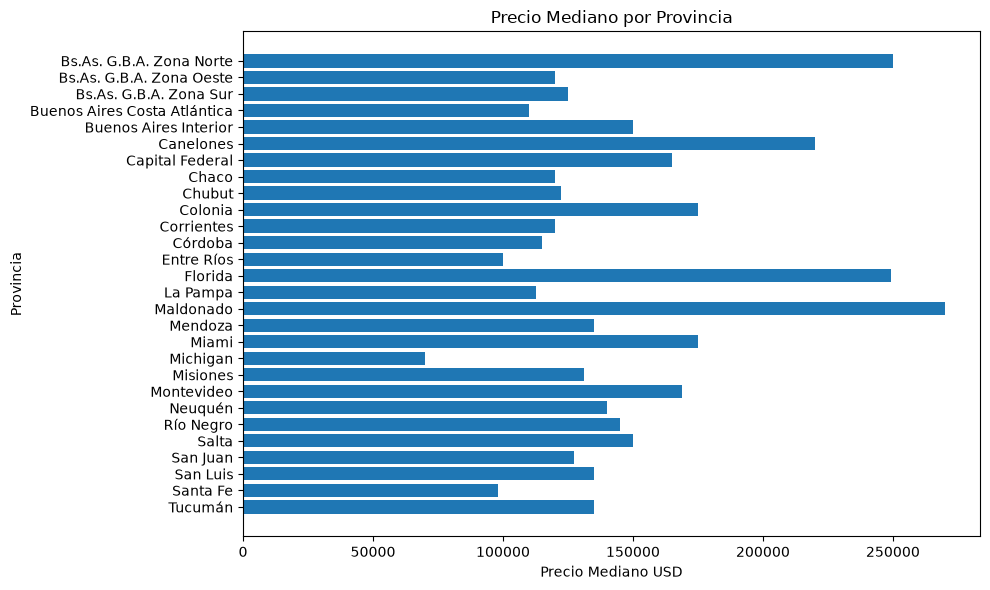

In [187]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    estadisticas.index,
    estadisticas["precio_mediano"]
)

plt.xlabel("Precio Mediano USD")
plt.ylabel("Provincia")
plt.title("Precio Mediano por Provincia")

# El mayor queda arriba
plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()


## Ejercicio 6 — Correlaciones: qué factores explican el precio

El cliente quiere saber qué características de una propiedad impactan más en su precio.

**Consigna:**

1. Antes de calcular nada, anotá tus predicciones:
    - superficie_m2 vs precio_usd: ¿positiva, negativa, sin relación?
    - rooms (ambientes) vs precio_usd: ¿positiva, negativa, sin relación?
    - superficie_m2 vs rooms: ¿positiva, negativa, sin relación?

2. Calcula la matriz de correlación entre las variables numéricas relevantes

3. ¿Cuántas predicciones acertaste? Para las que no acertaste, ¿qué puede explicar la diferencia?
4. ¿Cuál es la variable que más se correlaciona con el precio? ¿Es lo que esperabas?
```

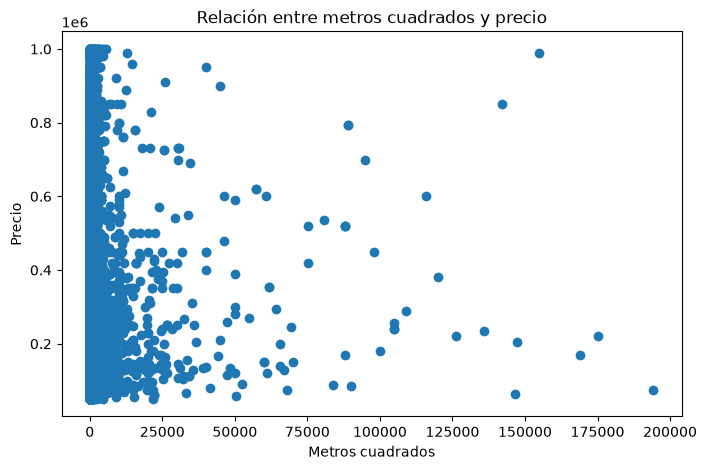

In [ ]:
## A mayor cantidad de superficie_m2 relacion positiva con el precio_usd
## A mayor cantidad de cantidad de habitaciones relacion positiva con el precio_usd
## Relacion positiva entre la superficie y la cantidad de ambientes
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df_filtrado["superficie_total"],
    df_filtrado["precio"]
)

plt.xlabel("Metros cuadrados")
plt.ylabel("Precio")
plt.title("Relación entre metros cuadrados y precio")

plt.show()


"Al analizar la relación entre la superficie total y el precio mediante un gráfico de dispersión, no se observa una relación lineal fuerte. Si bien existe una tendencia esperada donde propiedades más grandes pueden alcanzar mayores precios, la dispersión de los datos y la presencia de valores extremos dificultan establecer una relación directa."

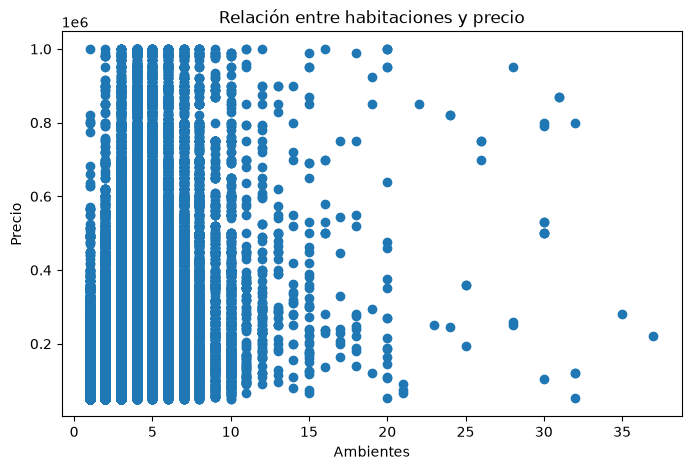

In [193]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df_filtrado["habitaciones"],
    df_filtrado["precio"]
)

plt.xlabel("Ambientes")
plt.ylabel("Precio")
plt.title("Relación entre habitaciones y precio")

plt.show()

"La relación entre la cantidad de habitaciones y el precio presenta una tendencia positiva débil. Si bien las propiedades con mayor cantidad de ambientes pueden alcanzar valores más elevados, existe una alta dispersión, indicando que otras variables como ubicación, superficie, estado de la propiedad y características adicionales tienen mayor influencia sobre el precio."

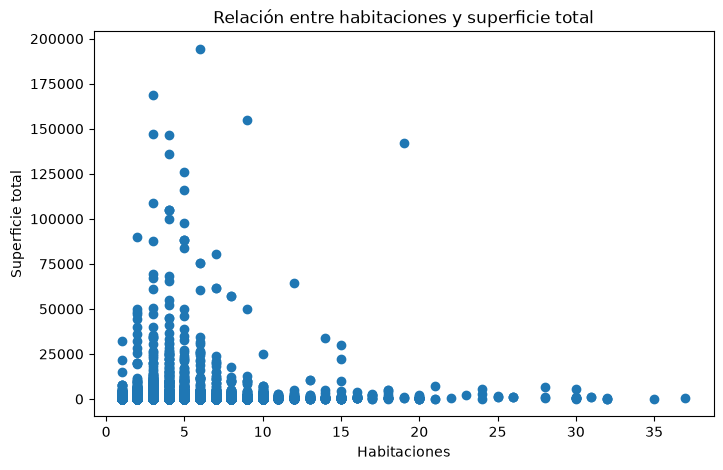

In [194]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df_filtrado["habitaciones"],
    df_filtrado["superficie_total"]
)

plt.xlabel("Habitaciones")
plt.ylabel("Superficie total")
plt.title("Relación entre habitaciones y superficie total")

plt.show()

"El gráfico muestra una relación positiva débil entre la cantidad de habitaciones y la superficie total. Si bien existe una tendencia donde las propiedades con mayor cantidad de habitaciones pueden presentar mayores superficies, la gran dispersión de los datos indica que la cantidad de habitaciones por sí sola no explica completamente el tamaño de la propiedad. Además, se observan valores atípicos que pueden influir en la relación."

## Ejercicio 7 — Comparación estadística por tipo de propiedad
 
El cliente todavía no definió si quiere invertir en un departamento, una casa o un PH. Necesita comparar los tres mercados usando todos los estadísticos que calculaste hasta ahora.
 
**Consigna:** Para cada tipo de propiedad (Departamento, Casa, PH), calcula la media, mediana del precio_usd, desviación estándar del precio_usd, media y mediana del precio_m2 y los percentiles 25 y 75 del precio_usd. Luego muestra el resultado como una tabla comparativa.
 
Por ultimo responde en comentarios:

1. ¿En qué tipo de propiedad la diferencia entre media y mediana es mayor? ¿Qué implica eso para el cliente que quiere saber "cuánto cuesta típicamente"?
2. ¿Qué tipo de propiedad tiene mayor dispersión de precios? ¿Eso es bueno o malo para un inversor que quiere predecir costos?
3. ¿El tipo más caro en precio absoluto también es el más caro en precio por m²? ¿Qué le dirías al cliente sobre esto?
4. ¿En qué tipo de propiedad el rango intercuartil (P75 - P25) es más amplio? ¿Qué dice eso sobre la homogeneidad de ese mercado?
5. Grafica la distribución de precios para los tres tipos en el mismo histograma (usa alpha=0.5 para transparencia y una leyenda que los diferencie)

In [ ]:
tabla_comparativa = df_filtrado.groupby("tipo_propiedad").agg(
    media_precio=("precio", "mean"),
    mediana_precio=("precio", "median"),
    desvio_precio=("precio", "std"),
    media_m2=("precio_m2", "mean"),
    mediana_m2=("precio_m2", "median")
)

tabla_comparativa

percentiles = df_filtrado.groupby("tipo_propiedad")["precio"].quantile(
    [0.25, 0.50, 0.75]
)

tipo_propiedad      
Casa            0.25    140000.0
                0.50    240000.0
                0.75    380000.0
Departamento    0.25     92000.0
                0.50    136600.0
                0.75    220000.0
PH              0.25    100000.0
                0.50    150000.0
                0.75    230000.0
Name: precio, dtype: float64

In [204]:
# Calcular percentiles y convertirlos en tabla

percentiles = (
    df_filtrado.groupby("tipo_propiedad")["precio"]
    .quantile([0.25, 0.50, 0.75])
    .unstack()
)

percentiles


## Renombramos:

percentiles.columns = ["P25", "P50", "P75"]

percentiles


# 1) Diferencia entre media y mediana del precio

diferencia_media_mediana = (
    tabla_comparativa["media_precio"] -
    tabla_comparativa["mediana_precio"]
)

diferencia_media_mediana

# 2) Dispersión de precios (desviación estándar)

tabla_comparativa["desvio_precio"]

# 3) Comparación precio absoluto vs precio por m²

tabla_comparativa[["media_precio", "media_m2"]]

# 4) Rango intercuartil

rango_intercuartil = percentiles["P75"] - percentiles["P25"]

rango_intercuartil



tipo_propiedad
Casa            240000.0
Departamento    128000.0
PH              130000.0
dtype: float64

# Conclusión:
#
# El tipo de propiedad con mayor rango intercuartil es la Casa,
# con una diferencia de 240000 USD entre el percentil 75 y el percentil 25.
#
# Esto indica que el mercado de casas presenta mayor variabilidad de precios
# dentro del 50% central de las propiedades analizadas.
#
# En comparación, Departamentos y PH tienen rangos intercuartiles menores,
# por lo que sus precios son más concentrados y presentan mayor homogeneidad.
#
# Para un inversor, un rango intercuartil amplio significa que existe una
# mayor diversidad de opciones dentro del mismo segmento, pero también puede
# dificultar la estimación de costos futuros.

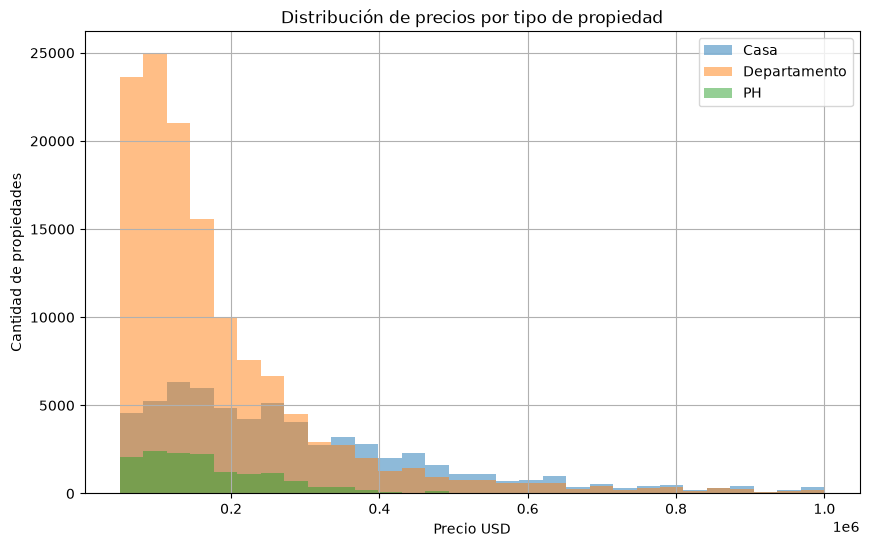

In [199]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df_filtrado[df_filtrado["tipo_propiedad"]=="Casa"]["precio"].hist(
    bins=30,
    alpha=0.5,
    label="Casa"
)

df_filtrado[df_filtrado["tipo_propiedad"]=="Departamento"]["precio"].hist(
    bins=30,
    alpha=0.5,
    label="Departamento"
)

df_filtrado[df_filtrado["tipo_propiedad"]=="PH"]["precio"].hist(
    bins=30,
    alpha=0.5,
    label="PH"
)

plt.xlabel("Precio USD")
plt.ylabel("Cantidad de propiedades")
plt.title("Distribución de precios por tipo de propiedad")

plt.legend()
plt.show()

## Informe para el cliente

Con todo el análisis hecho, escribí un bloque de código que genere un reporte ejecutivo respondiendo estas preguntas concretas del cliente:

1. **¿Cuánto cuesta una propiedad "típica" en Argentina?** (usa el estadístico que mejor represente eso y justificá por qué)

2. **¿Cuál es la provincia con mejor relación precio/m²?**

3. **¿Cuánto impacta la superficie en el precio?** (usa la correlación para responder)

4. **¿Hay alguna provincia donde el mercado sea especialmente volátil?** (usa la desviación estándar para responder)

5. **¿Cuál es el rango de precios donde se encuentra la mayor parte del mercado?** (usa percentiles para definir ese rango)

In [ ]:
print("=" * 56)
print("INFORME DE MERCADO INMOBILIARIO — ARGENTINA")
print("Fuente: Properati Argentina Dataset")
print("=" * 56)

# Tu reporte acá — cada punto respondido con números concretos
# y una oración de interpretación para el cliente

→ [Ver solución orientativa](./solucion.md) *(intenta primero — en este ejercicio no hay una única respuesta correcta)*